Імпорт бібліотек

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

Завантаження датасету

In [48]:
path = os.path.join('..', 'data', 'raw', 'global_graduate_employability_index.csv')

df = pd.read_csv(path)
df.head()

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023


Аналіз даних

In [49]:
df.shape

(3500, 18)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country                            3500 non-null   object 
 1   Region                             3500 non-null   object 
 2   University_Name                    3500 non-null   object 
 3   Degree_Level                       3500 non-null   object 
 4   Field_of_Study                     3500 non-null   object 
 5   Graduation_Year                    3500 non-null   int64  
 6   Employment_Rate_6_Months (%)       3500 non-null   float64
 7   Employment_Rate_12_Months (%)      3500 non-null   float64
 8   Average_Starting_Salary_USD        3500 non-null   int64  
 9   Top_Industry                       3500 non-null   object 
 10  Job_Role                           3500 non-null   object 
 11  Skill_1                            3500 non-null   objec

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Graduation_Year,3500.0,2020.021143,3.198601,2015.0,2017.0,2020.0,2023.00,2025.0
Employment_Rate_6_Months (%),3500.0,85.735486,6.986723,65.5,80.7,85.6,90.90,99.0
Employment_Rate_12_Months (%),3500.0,90.409857,6.743580,68.0,85.5,90.6,96.00,100.0
Average_Starting_Salary_USD,3500.0,64668.000000,30727.510224,-1200.0,39400.0,63900.0,85400.00,189400.0
Skill_Demand_Score (1–100),3500.0,65.187429,14.710632,30.0,55.0,64.0,75.00,100.0
Remote_Work_Availability (%),3500.0,40.060886,30.318816,5.0,10.6,37.3,68.30,90.0
Employer_Reputation_Score (1–100),3500.0,69.742286,14.243037,40.0,60.0,70.0,79.25,100.0
Year,3500.0,2020.021143,3.198601,2015.0,2017.0,2020.0,2023.00,2025.0


**Відсутні пропущені дані**

In [52]:
df.isnull().sum()

Country                              0
Region                               0
University_Name                      0
Degree_Level                         0
Field_of_Study                       0
Graduation_Year                      0
Employment_Rate_6_Months (%)         0
Employment_Rate_12_Months (%)        0
Average_Starting_Salary_USD          0
Top_Industry                         0
Job_Role                             0
Skill_1                              0
Skill_2                              0
Skill_3                              0
Skill_Demand_Score (1–100)           0
Remote_Work_Availability (%)         0
Employer_Reputation_Score (1–100)    0
Year                                 0
dtype: int64

In [53]:
df.nunique()

Country                                21
Region                                  5
University_Name                        46
Degree_Level                            3
Field_of_Study                          7
Graduation_Year                        11
Employment_Rate_6_Months (%)          304
Employment_Rate_12_Months (%)         274
Average_Starting_Salary_USD          1131
Top_Industry                            7
Job_Role                               29
Skill_1                                34
Skill_2                                34
Skill_3                                34
Skill_Demand_Score (1–100)             71
Remote_Work_Availability (%)          758
Employer_Reputation_Score (1–100)      61
Year                                   11
dtype: int64

In [54]:
df.columns.values.tolist()

['Country',
 'Region',
 'University_Name',
 'Degree_Level',
 'Field_of_Study',
 'Graduation_Year',
 'Employment_Rate_6_Months (%)',
 'Employment_Rate_12_Months (%)',
 'Average_Starting_Salary_USD',
 'Top_Industry',
 'Job_Role',
 'Skill_1',
 'Skill_2',
 'Skill_3',
 'Skill_Demand_Score (1–100)',
 'Remote_Work_Availability (%)',
 'Employer_Reputation_Score (1–100)',
 'Year']

Значення колонок:
- Country - країна, де знаходиться університет
- Region - глобальний географічний регіон (Європа, Північна Америка, і т.п.)
- University_Name - назва університету
- Degree_Level - рівень завершеної вищої освіти (Бакалавр, Магістр, PhD)
- Field_of_Study - освітній напрямок (Комп'ютерні науки, Інженерія, тощо)
- Graduation_Year - рік випуску з університету
- Employment_Rate_6_Months (%) - відсоток працевлаштування протягом перших 6 місяців
- Employment_Rate_12_Months (%) - відсоток працевлаштування протягом року
- Average_Starting_Salary_USD - початкова заробітня плата (в доларах)
- Top_Industry - типова індустрія працевлаштування випускника
- Job_Role - отримана робоча посада
- Skill_1 - найважливіша технічна або соціальна навичка для відповідної робочої посади
- Skill_2 - друга важлива навичка для відповідної робочої посади
- Skill_3 - третя допоміжна навичка за відповідним фахом або схожим фахом
- Skill_Demand_Score (1–100) - Індексний бал, що відображає ринковий попит на навички випускника
- Remote_Work_Availability (%) - орієнтований відсоток посад у цій галузі, які пропонують варіанти віддаленої роботи
- Employer_Reputation_Score (1–100) - рейтинг репутації роботодавця
- Year - як і Graduation_Year

Для впевненості в однаковості двох колонок:

In [55]:
print(df['Year'].equals(df['Graduation_Year']))

True


Для аналізу залишимо колонку Graduation_Year та Year відповідно. Перед початком моделювання слід прибрати колонку Graduation_Year.

**Одновимірний аналіз таргет змінної**

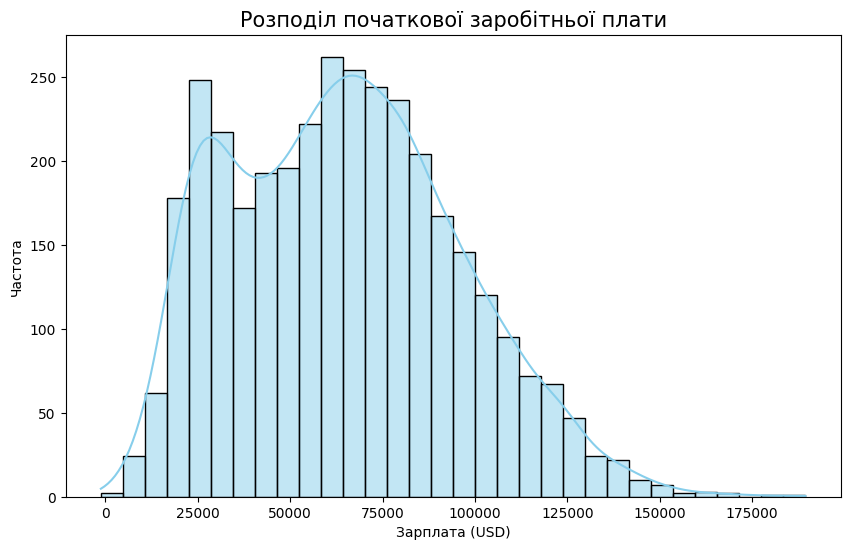

In [56]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Average_Starting_Salary_USD'], kde=True, color='skyblue')
plt.title('Розподіл початкової заробітньої плати', fontsize=15)
plt.xlabel('Зарплата (USD)')
plt.ylabel('Частота')
plt.show()

На графіку гістограми можна побачити бімодальний розподіл. Це означає що принаймні є дві групи, які по різному впливають на початкову зарплату випускника - перша група пропонує близько до 30к доларів в рік, а друга - до 75к в доларах як початкову зп за рік.

Першим припущенням була різниця в отриманих рівнях вищої освіти, відповідно:

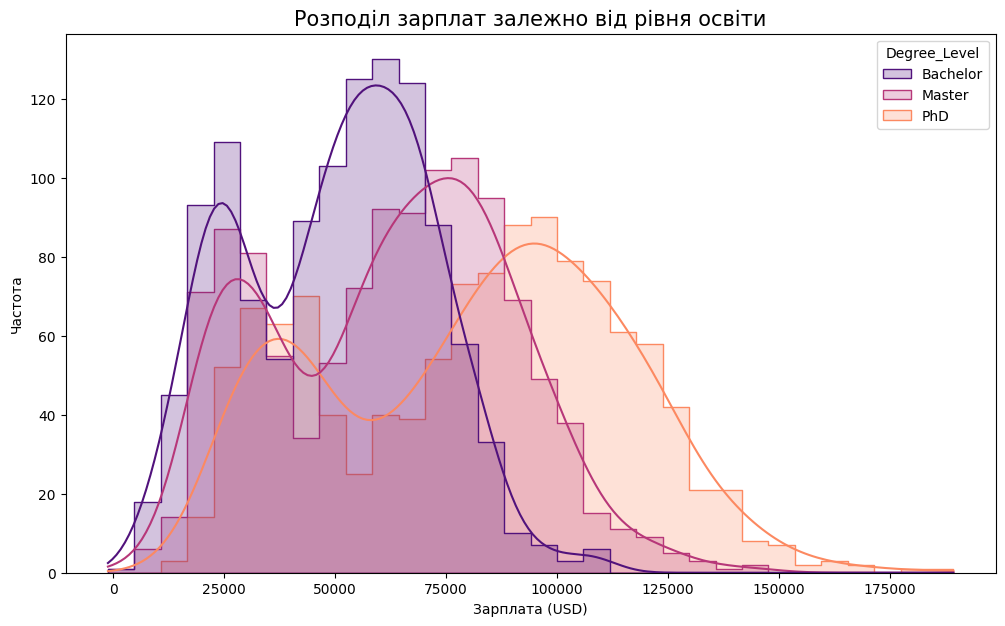

In [58]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Average_Starting_Salary_USD', hue='Degree_Level',
            kde=True, palette='magma', element='step')
plt.title('Розподіл зарплат залежно від рівня освіти', fontsize=15)
plt.xlabel('Зарплата (USD)')
plt.ylabel('Частота')
plt.show()

Гіпотеза була спростована: в кожній з груп вищої освіти спостерігаєтяс бімодальний розподіл. На заробітню плату впливає інша прихована змінна.

Наступне припущення: на заробітню плату найбільше впливає регіон працевлаштування.

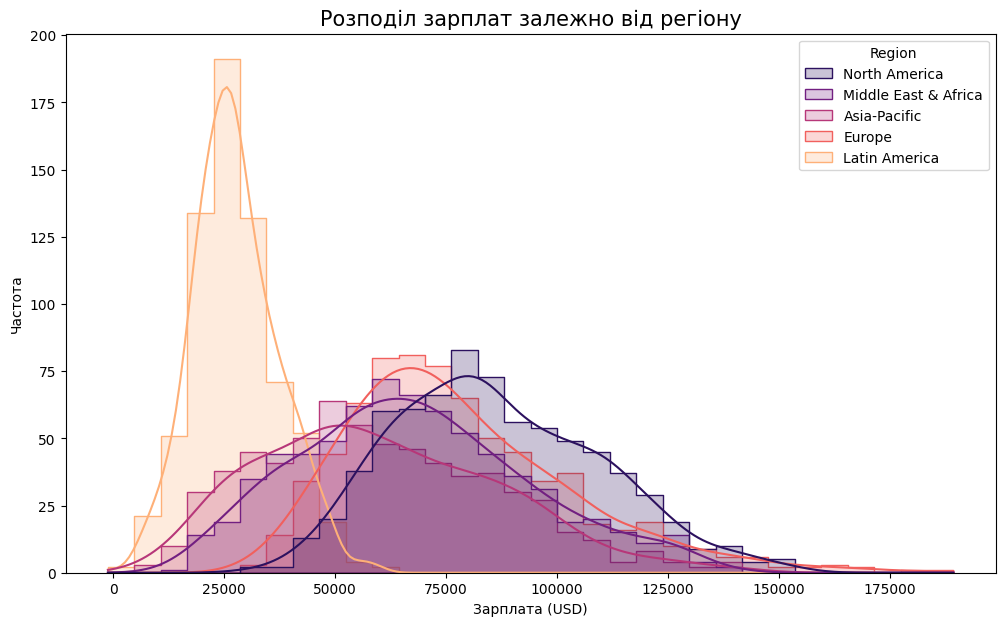

In [59]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Average_Starting_Salary_USD', hue='Region',
            kde=True, palette='magma', element='step')
plt.title('Розподіл зарплат залежно від регіону', fontsize=15)
plt.xlabel('Зарплата (USD)')
plt.ylabel('Частота')
plt.show()

Одразу можна побачити що гіпотеза була підтверджена.

На графіку розподілу гістограм можна побачити, що найчастіше в Латинській Америці випускникам, незалежно від обраної сфери працевлаштування чи рівню освіти, пропонують початкову зарплату в 25к доларів на рік. Тим часом як інші регіони в середньому надають вищу початкову заробітню плату, але з більш шумними даними (через великий розкид між бідними та багатими вакансіями або розміщенням в регіонах "островів" надвисоких зарплат як от Дубай, Катар, Сінгапур і т.п.).

Аналіз підтверджує, що модель має врахувати регіональні економічні розбіжності. Латинська Америка демонструє стабільно низький старт, що може бути пов'язано з роллю регіону як аутсорсинг-майданчика, тоді як Північна Америка є лідером за рахунок концентрації технологічних гігантів.

Побудумоємо також коробкочасті діаграми для більш чистого аналізу

Почну з одновимірної діаграми зарплат:

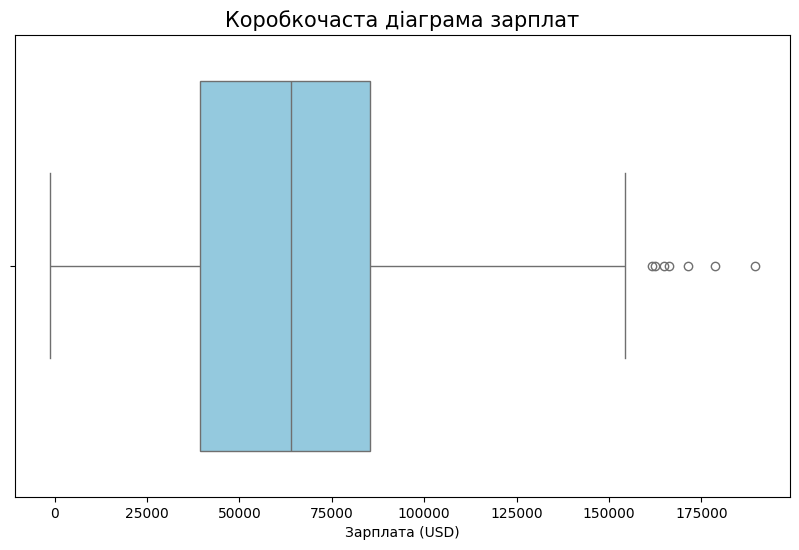

In [61]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Average_Starting_Salary_USD'], color='skyblue')
plt.title('Коробкочаста діаграма зарплат', fontsize=15)
plt.xlabel('Зарплата (USD)')
plt.show()

На графіку можна спостерігати викиди (аномалії) - найімовірніше деякі випускники отримували пропозиції з аномально високими початковими заробітніми платами на посади.

Для детальнішого аналізу побудуємо ці діаграми по категоріям: рівень вищої освіти та регіон.

C:\Users\Kate\AppData\Local\Temp\ipykernel_336\881154921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Average_Starting_Salary_USD', y='Degree_Level', palette='Set3')


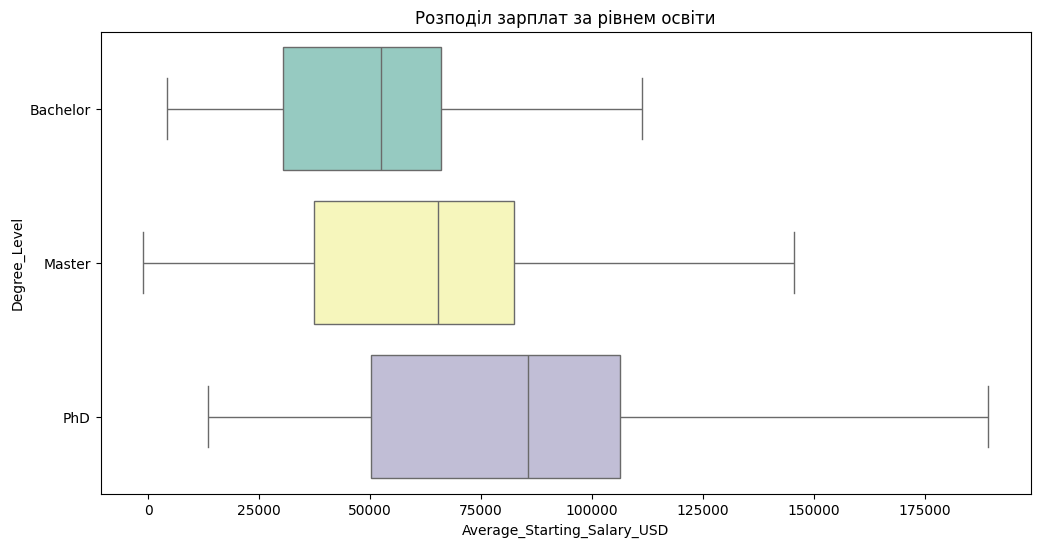

In [62]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Average_Starting_Salary_USD', y='Degree_Level', palette='Set3')
plt.title('Розподіл зарплат за рівнем освіти')
plt.show()

На диво, викиди тепер тут не спостерігаються. Принаймні в межах кожного здобутого рівня освіти є баланс. Медіана постійно рухається вправо по осі x з кожною зміною рівня вищої освіти випускника. Зазвичай медіана спостерігається на кінці кожної з попередньої коробки попередньої вищої освіти.

З цікавого: мінімальна заробітня плата для магістра менша за мінімальну бакалавра, що може означати що на зарплатню тут може впливати конкретний освітній напрямок або отриамна робоча позиція або сам регіон.

Побудуємо коробкочасту діаграму за регіонами

C:\Users\Kate\AppData\Local\Temp\ipykernel_336\894146552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Average_Starting_Salary_USD', y='Region', palette='Set3')


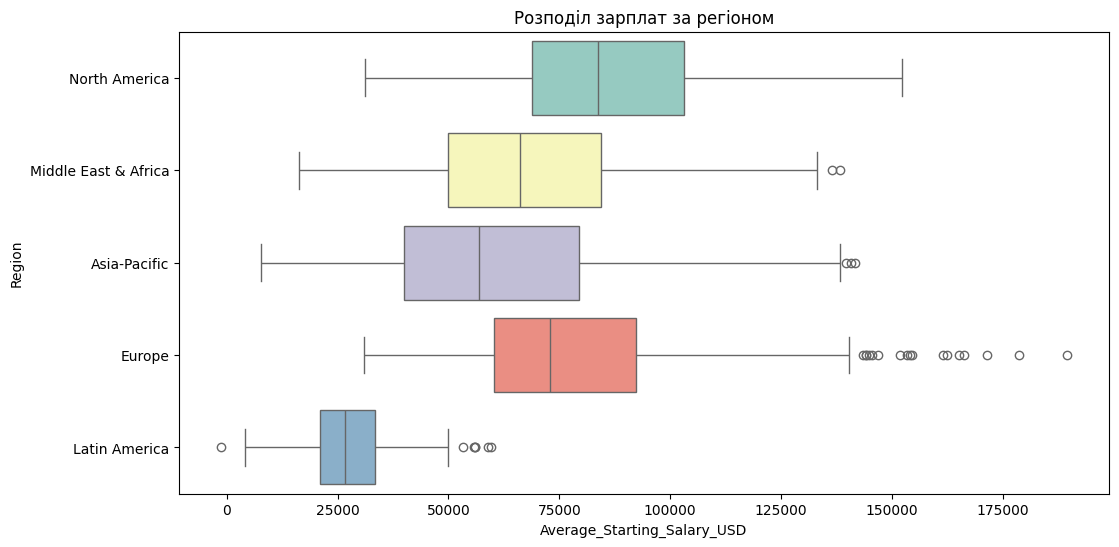

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Average_Starting_Salary_USD', y='Region', palette='Set3')
plt.title('Розподіл зарплат за регіоном')
plt.show()

Регіони **Europe** та **North America** демонструють найбільший потенціал для високих зарплат, проте мають значну кількість викидів (outliers), що вказує на специфічні високооплачувані ніші.

**Asia-Pacific** характеризується найбільшою дисперсією (розкидом), що відображає економічну різнорідність країн регіону.

**Latin America** є найбільш гомогенним регіоном з низькою медіанною зарплати, що створює бімодальний пік у загальному розподілі таргет-змінної.

Проведемо кореляційний аналіз

In [65]:
cols_to_corr = ['Average_Starting_Salary_USD', 'Degree_Level', 'Region', 
                'Employment_Rate_6_Months (%)', 'Employment_Rate_12_Months (%)', 
                'Remote_Work_Availability (%)']

df_encoded = pd.get_dummies(df[cols_to_corr], columns=['Degree_Level','Region'])

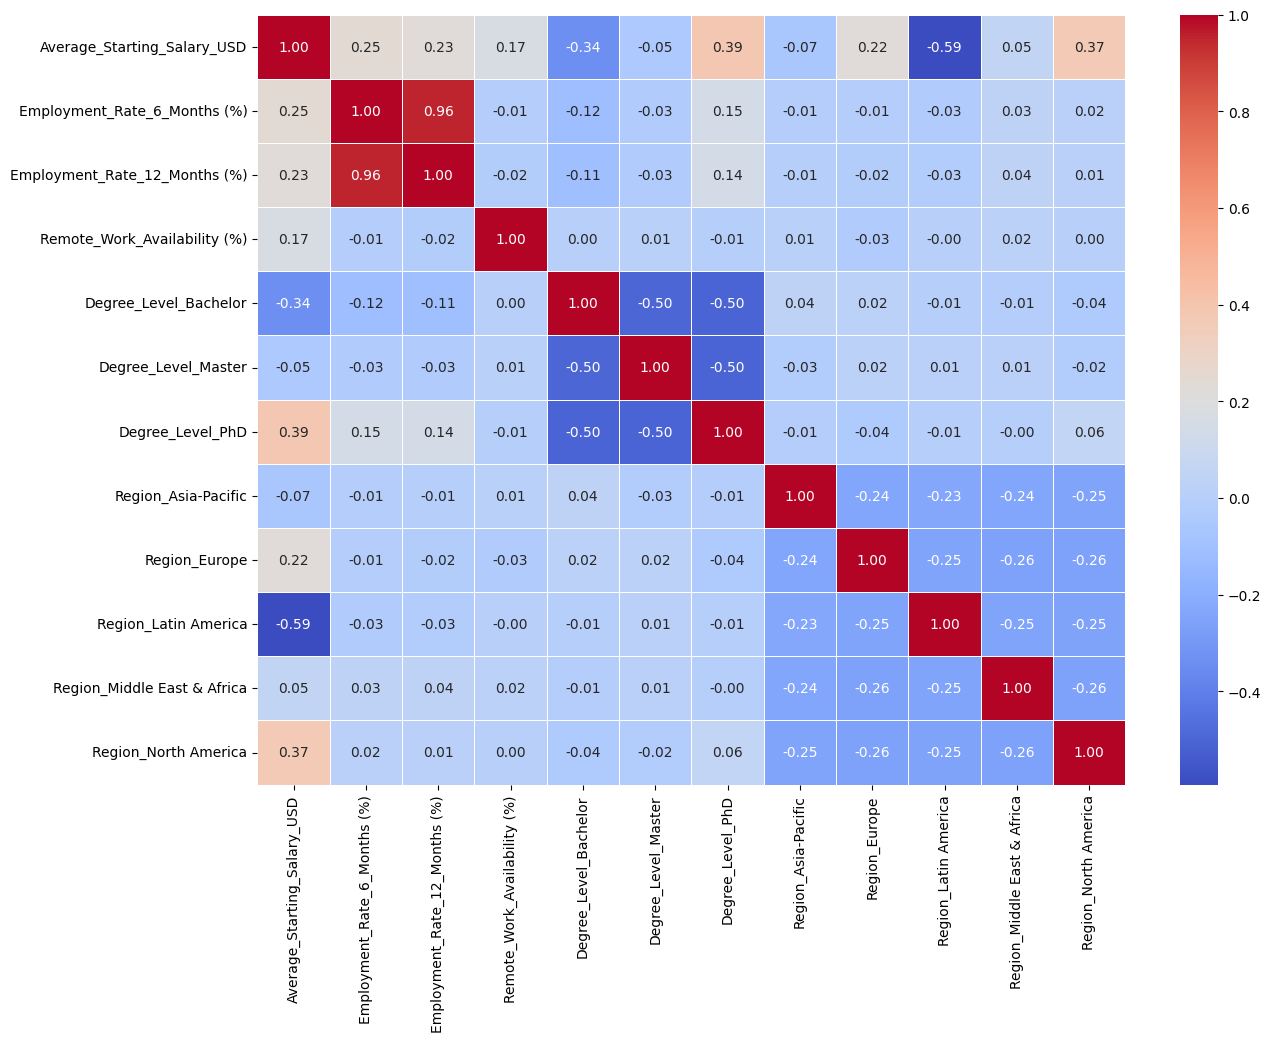

In [66]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidth=0.5)
plt.show()

Проведений аналіз матриці кореляції (теплової карти) та візуалізація розподілів дозволяють виділити ключові закономірності, що визначають рівень оплати праці випускників:

**1. Ключові предиктори цільової змінної (`Salary`)**
- **Географічний фактор:** Найсильніший вплив на зарплату має регіональна приналежність. Спостерігається значна негативна кореляція з регіоном **Latin America (-0.59)**, що підтверджує візуальну аномалію ("лівий пік" на гістограмі). Натомість **North America (0.37)** та **Europe (0.22)** мають позитивний зв'язок із вищим рівнем доходу.

- **Рівень освіти:** Ступінь **PhD (0.39)** має найвищий позитивний вплив на стартову зарплату серед усіх освітніх рівнів. Водночас рівень **Bachelor (-0.34)** корелює з нижчими стартовими позиціями, що підтверджує гіпотезу про додану вартість наукового ступеня на ринку праці.

**2. Мультиколінеарність та дублювання даних**
- **Висока залежність:** Коефіцієнт кореляції між показниками працевлаштування за **6 місяців та 12 місяців становить 0.96**.

- **Інженерне рішення**: Такий високий зв'язок свідчить про надликовість даних. Для запобігання перенавчанню (overfitting) майбутньої моделі ШІ рекомендується залишити лише один із цих показників (наприклад, 6-місячний як більш критичний маркер успіху).

**3. Слабкі та приховані зв'язки**
- **Дистанційна робота:** Показник `Remote_Work_Availability` має слабку позитивну кореляцію з зарплатою **(0.17)**. Це свідчить про те, що можливість працювати віддалено є радше додатковим бонусом, а не основним фактором формування високої зарплати.

- **Репутація та швидкість пошуку:** Помірна кореляція між репутацією роботодавця та рівнем працевлаштування підтверджує, що відомі бренди швидше закривають вакансії випускниками, але не завжди пропонують пропорційно вищі зарплати в усіх регіонах одночасно.


**Резюме для моделювання:**
> Для розробки прогностичної моделі (наприклад, нейронної мережі) обов'язковими вхідними ознаками мають бути Region та Degree_Level, оскільки вони пояснюють найбільшу частку дисперсії цільової змінної. Бімодальний характер розподілу, спричинений регіоном Латинська Америка, вимагає особливої уваги при нормалізації даних перед подачею в модель.

Побудуємо лінійний графік за рівнем освіти та регіонами для часового аналізу

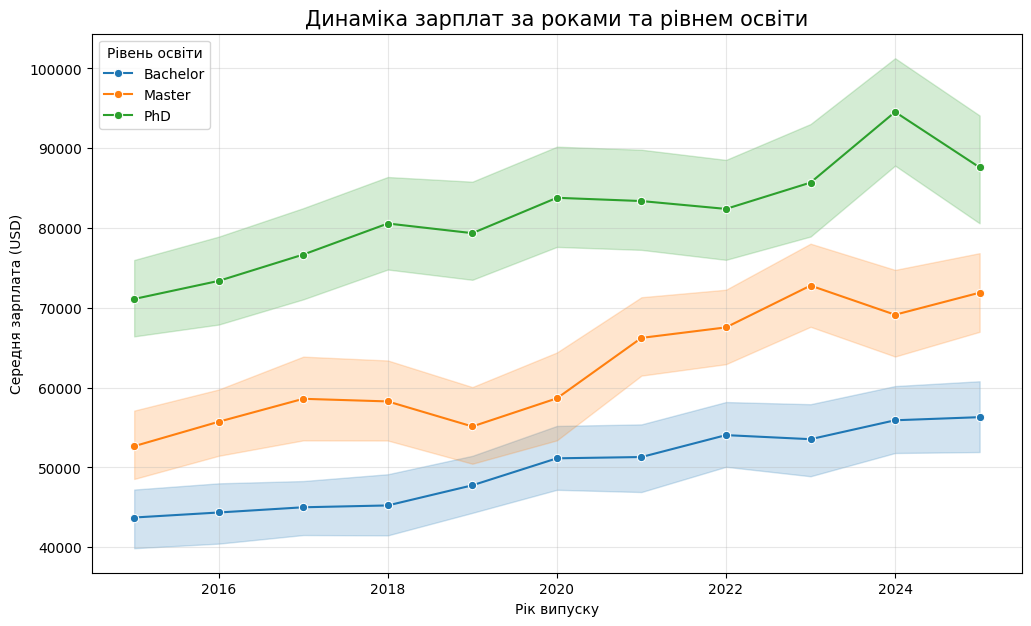

In [21]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Graduation_Year', y='Average_Starting_Salary_USD', 
             hue='Degree_Level', marker='o')

plt.title('Динаміка зарплат за роками та рівнем освіти', fontsize=15)
plt.ylabel('Середня зарплата (USD)')
plt.xlabel('Рік випуску')
plt.grid(True, alpha=0.3)
plt.legend(title='Рівень освіти')
plt.show()

Можна побачити, що на графіку спостерігається постійне зростання заробітніх плат для кожного рівня освіти.

Початкова зарплатня для бакалаврів постійно зростає та, наприклад, середня зарплата в 25 році досягла середньої зарплати магістра в 15 та 19 роках. На диво лише зарплата бакалавра нестримно зростала в 19 році, на противагу магістрам та докторантам.

Для магістрів видимий неймовірний приріст протягом 21 року, що більше наближало до заробітньої плати випускників PhD.

Для PhD випускників спостерігається пропорційне зростання зробітньої плати, особилво в 24 році і падінню в 25 році майже до рівня 23 року.

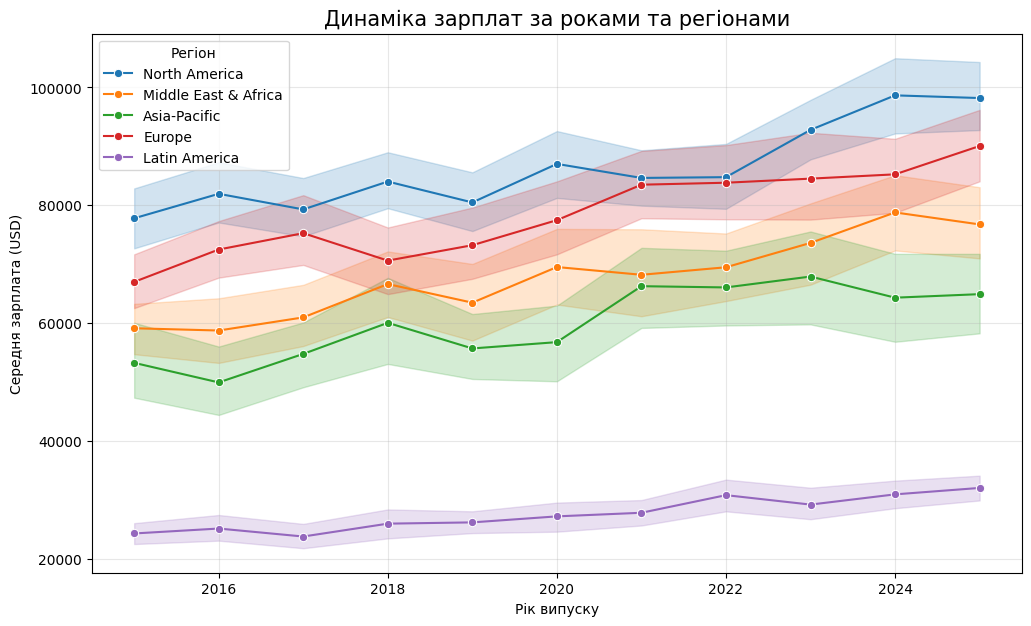

In [67]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Graduation_Year', y='Average_Starting_Salary_USD', 
             hue='Region', marker='o')

plt.title('Динаміка зарплат за роками та регіонами', fontsize=15)
plt.ylabel('Середня зарплата (USD)')
plt.xlabel('Рік випуску')
plt.grid(True, alpha=0.3)
plt.legend(title='Регіон')
plt.show()

Аналіз регіональної динаміки виявив **географічну сегментацію ринку**. Латинська Америка демонструє ознаки 'пастки середнього доходу': попри загальний висхідний тренд, розрив між нею та іншими регіонами лише збільшується.

З погляду машинного навчання, висока дисперсія (розкид) у регіонах **Asia-Pacific** та **Middle East & Africa** вказує на те, що для точного прогнозування в цих зонах моделі знадобляться додаткові ознаки (наприклад, конкретна країна або назва університету), тоді як для Латинської Америки та Північної Америки регіон сам по собі є самодостатнім і сильним предиктором.

**Аналіз впливу сектору економіки та рівня освіти на заробітну плату**

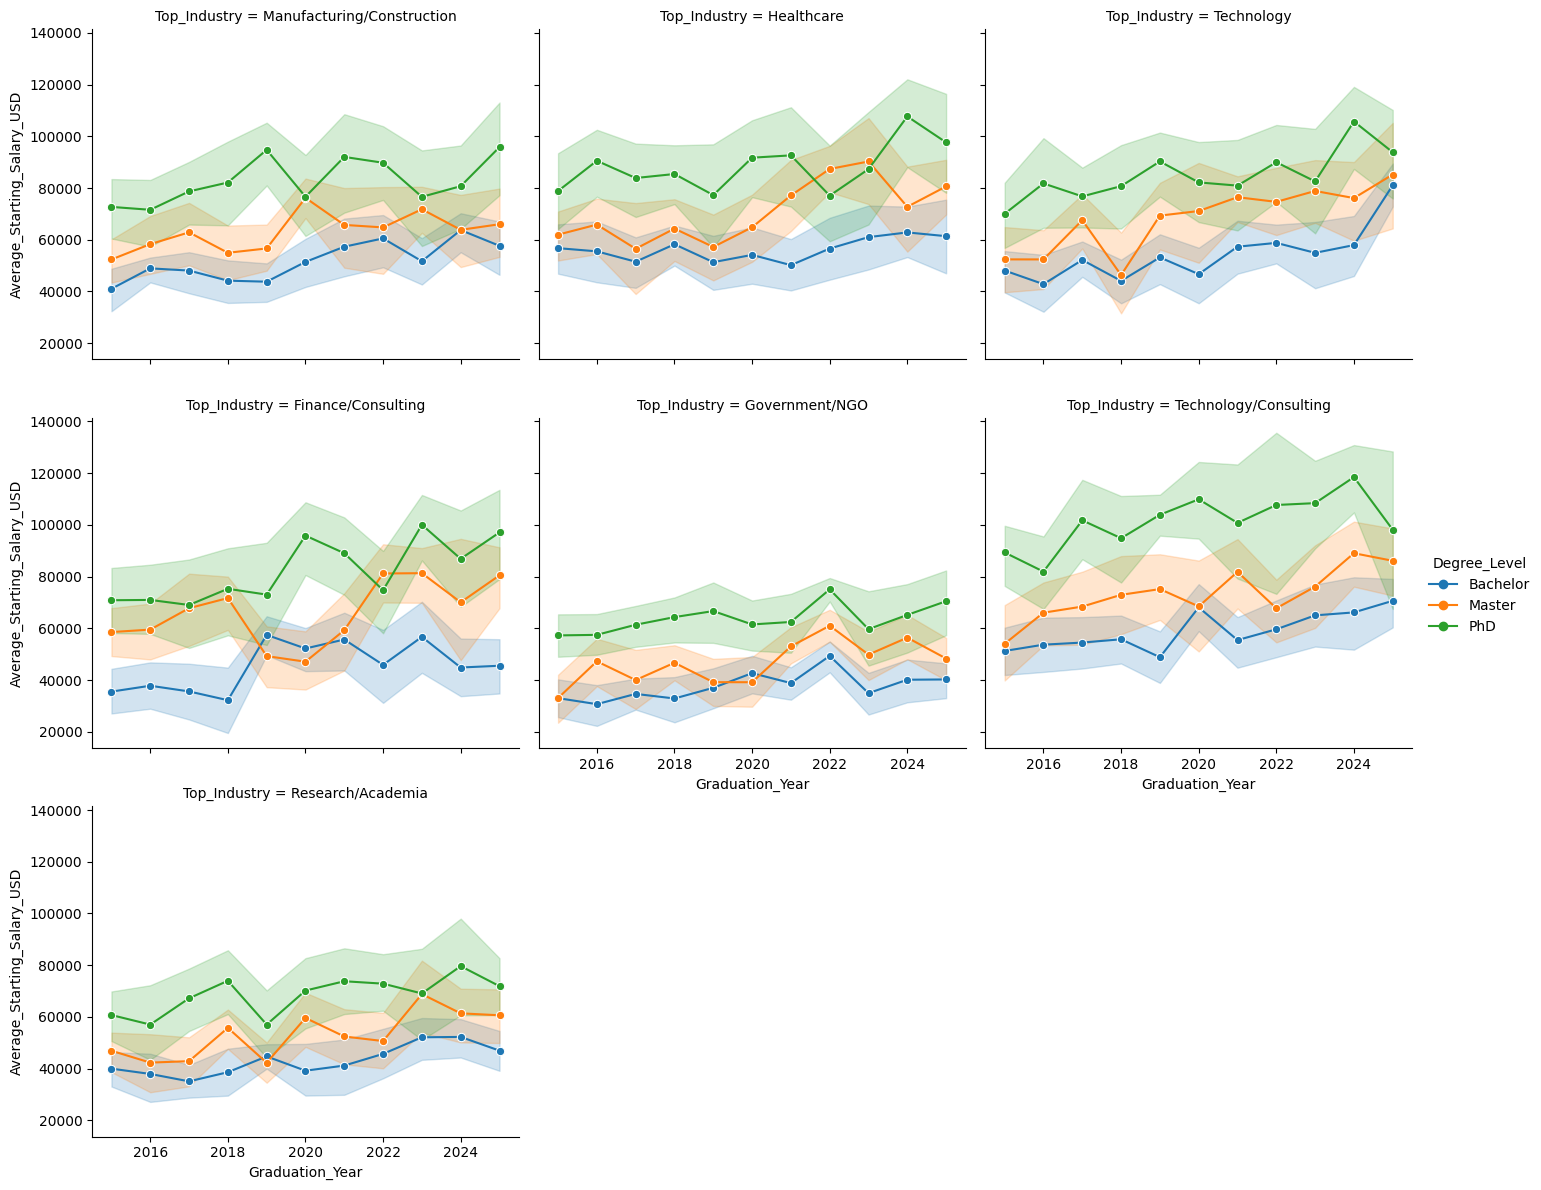

In [68]:
sns.relplot(
    data=df, x='Graduation_Year', y='Average_Starting_Salary_USD',
    hue='Degree_Level', col='Top_Industry', col_wrap=3,
    kind='line', marker='o', height=4, aspect=1.2
)

Останній етап візуального аналізу (`FacetGrid` лінійних графіків) дозволяє дослідити **взаємодію (interaction)** між трьома ключовими факторами: роком випуску, рівнем освіти та індустрією.

**1. Секторальна диференціація "освітньої премії"**
- **Technology & Consulting:** Демонструють найвищу чутливість до рівня освіти. Тут спостерігається максимальний розрив між ступенями: PhD отримує суттєву "премію" (досягаючи ~$120k), тоді як бакалаври стартують зі значно нижчої бази.

- **Healthcare:** Показує найбільш стабільну та прогнозовану структуру. Лінії різних ступенів освіти рухаються майже паралельно, що свідчить про фіксовані ринкові надбавки за кожен рівень кваліфікації.

- **Government/NGO & Research:** Мають найнижчу медіанну зарплату навіть для власників PhD (~$70k–$80k), що вказує на наявність "бюджетної стелі" в цих секторах.

**2. Волатильність та прогнозованість**
- **Finance/Consulting:** Характеризується найширшими довірчими інтервалами (тінями на графіку), що свідчить про високу дисперсію. Це вказує на те, що в цій індустрії диплом є менш надійним предиктором успіху, ніж в IT чи медицині.

- **Manufacturing/Construction:** Демонструє конвергенцію (зближення) ліній бакалаврів та магістрів, що може свідчити про низьку додану вартість магістерського ступеня для цього конкретного сектору.

**3. Тимчасові тренди**
- У більшості секторів спостерігається висхідний тренд після 2020 року, що корелює з глобальною інфляцією та підвищенням попиту на висококваліфікованих спеціалістів.

- Сектор **Technology** демонструє найбільш агресивне зростання для PhD-рівня, що відображає бум у сфері штучного інтелекту та великих даних.

**Висновок для Feature Engineering:**
> Цей аналіз доводить, що проста лінійна модель може не спрацювати, оскільки вплив освіти прямо залежить від обраної індустрії. Для майбутньої моделі ШІ (яку ти плануєш підготувати до квітня 2026 року) необхідно використовувати методи, що враховують нелінійні залежності, або створювати комбіновані ознаки (наприклад, Industry_Degree_Interaction).